# Análisis exploratorio del corpus
**Columnas de opinión sobre ciencia — El Espectador, El Tiempo, Semana (2018–2020)**

Este notebook realiza un análisis descriptivo del subcorpus administrativo/temático: distribución temporal, por periódico y por autor.

## 1. Carga y revisión general

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

In [4]:
ruta_corpus = "../../data/columnas_admin_ciencia.xlsx"

df = pd.read_excel(ruta_corpus, engine="openpyxl")

# Variables derivadas útiles para todo el análisis
df['Año']       = df['Fecha'].dt.year
df['Mes']       = df['Fecha'].dt.month
df['AñoMes']   = df['Fecha'].dt.to_period('M')   # período mensual
df['n_tokens']  = df['Texto'].str.split().str.len()  # longitud aproximada

print(f"Dimensiones: {df.shape}")
print(f"Periodo cubierto: {df['Fecha'].min().date()} → {df['Fecha'].max().date()}")
df.info()

Dimensiones: (2053, 11)
Periodo cubierto: 2018-01-01 → 2020-12-30
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2053 entries, 0 to 2052
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Diario    2053 non-null   object        
 1   Autor     2053 non-null   object        
 2   Fecha     2053 non-null   datetime64[ns]
 3   Título    2053 non-null   object        
 4   Texto     2053 non-null   object        
 5   Vínculo   2053 non-null   object        
 6   ID        2053 non-null   int64         
 7   Año       2053 non-null   int32         
 8   Mes       2053 non-null   int32         
 9   AñoMes    2053 non-null   period[M]     
 10  n_tokens  2053 non-null   int64         
dtypes: datetime64[ns](1), int32(2), int64(2), object(5), period[M](1)
memory usage: 160.5+ KB


In [5]:
# Vista rápida
df[['Diario', 'Autor', 'Fecha', 'Título', 'n_tokens']].head(5)

,Diario,Autor,Fecha,Título,n_tokens
0,El Espectador,Luis I. Sandoval M.,2018-01-01,"Clara, Humberto, Gustavo: la esperanza",590
1,El Espectador,Pascual Gaviria,2018-01-02,Elecciones típicas,629
2,El Espectador,Marcos Peckel,2018-01-02,Autócratas,479
3,El Espectador,Vivian Newman,2018-01-05,Deliberación en la división,507
4,El Espectador,Carolina Botero Cabrera,2018-01-05,Retos en la ciberpolítica de 2018 (II),516


## 2. Totales generales

In [6]:
resumen = pd.DataFrame({
    'Total columnas'   : [len(df)],
    'Autores únicos'   : [df['Autor'].nunique()],
    'Periódicos'       : [df['Diario'].nunique()],
    'Tokens totales'   : [df['n_tokens'].sum()],
    'Tokens promedio'  : [df['n_tokens'].mean().round(1)],
})
resumen

,Total columnas,Autores únicos,Periódicos,Tokens totales,Tokens promedio
0,2053,330,3,1433081,698.0


## 3. Distribución por periódico

In [5]:
por_diario = (
    df.groupby('Diario')
      .agg(
          n_columnas   = ('ID',       'count'),
          n_autores    = ('Autor',    'nunique'),
          tokens_total = ('n_tokens', 'sum'),
          tokens_prom  = ('n_tokens', 'mean'),
      )
      .assign(pct=lambda x: (x['n_columnas'] / x['n_columnas'].sum() * 100).round(1))
      .sort_values('n_columnas', ascending=False)
)
por_diario.style.format({'tokens_prom': '{:.1f}', 'pct': '{:.1f}%'})

,n_columnas,n_autores,tokens_total,tokens_prom,pct
Diario,,,,,
El Espectador,1571,167,1079514,687.2,76.5%
El Tiempo,288,117,185548,644.3,14.0%
Semana,194,52,168019,866.1,9.4%


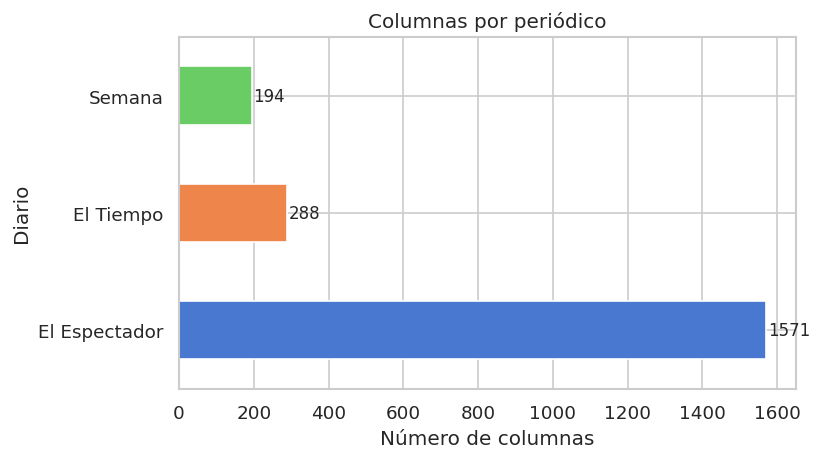

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
por_diario['n_columnas'].plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(por_diario)))
ax.set_xlabel('Número de columnas')
ax.set_title('Columnas por periódico')
for i, v in enumerate(por_diario['n_columnas']):
    ax.text(v + 5, i, str(v), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('fig_por_diario.png', bbox_inches='tight')
plt.show()

## 4. Distribución mensual

In [7]:
# Serie mensual total
mensual = (
    df.groupby('AñoMes')
      .size()
      .rename('n_columnas')
      .reset_index()
)
mensual['AñoMes_dt'] = mensual['AñoMes'].dt.to_timestamp()
mensual.head()

,AñoMes,n_columnas,AñoMes_dt
0,2018-01,70,2018-01-01
1,2018-02,58,2018-02-01
2,2018-03,71,2018-03-01
3,2018-04,68,2018-04-01
4,2018-05,105,2018-05-01


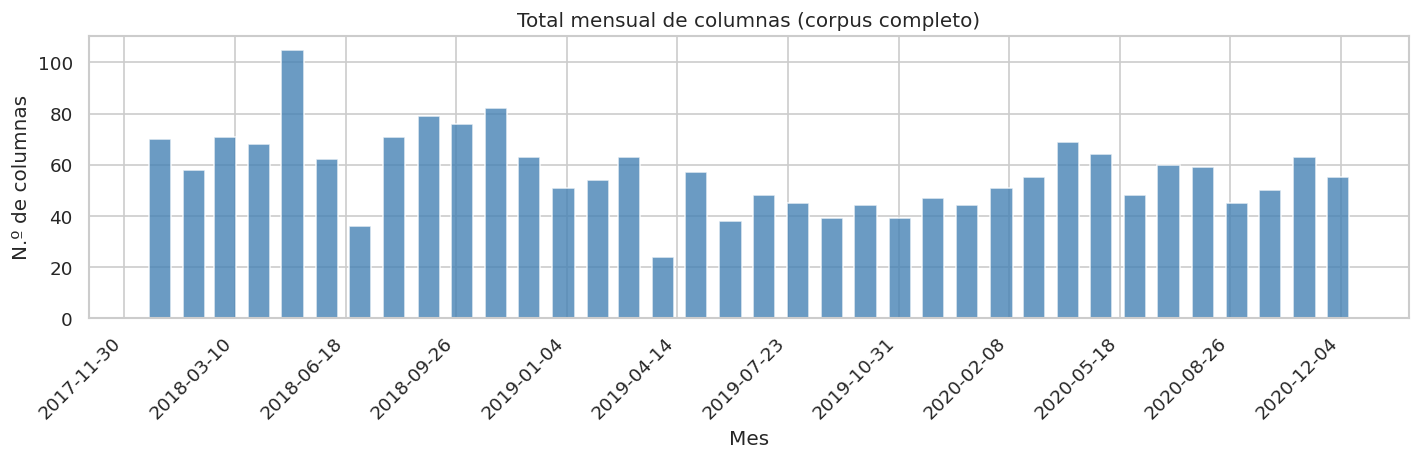

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(mensual['AñoMes_dt'], mensual['n_columnas'], width=20, color='steelblue', alpha=0.8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(12))
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('Mes')
ax.set_ylabel('N.º de columnas')
ax.set_title('Total mensual de columnas (corpus completo)')
plt.tight_layout()
plt.savefig('fig_mensual_total.png', bbox_inches='tight')
plt.show()

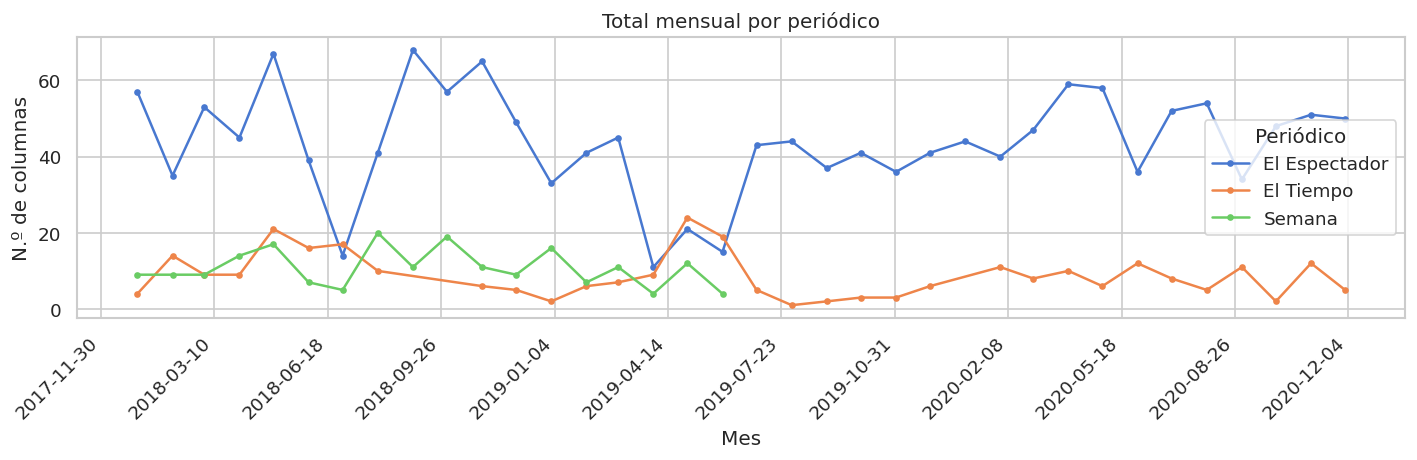

In [9]:
# Serie mensual desglosada por periódico
mensual_diario = (
    df.groupby(['AñoMes', 'Diario'])
      .size()
      .rename('n_columnas')
      .reset_index()
)
mensual_diario['AñoMes_dt'] = mensual_diario['AñoMes'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
for diario, grupo in mensual_diario.groupby('Diario'):
    ax.plot(grupo['AñoMes_dt'], grupo['n_columnas'], marker='o', markersize=3, label=diario)
ax.legend(title='Periódico')
ax.xaxis.set_major_locator(ticker.MaxNLocator(12))
plt.xticks(rotation=45, ha='right')
ax.set_xlabel('Mes')
ax.set_ylabel('N.º de columnas')
ax.set_title('Total mensual por periódico')
plt.tight_layout()
plt.savefig('fig_mensual_por_diario.png', bbox_inches='tight')
plt.show()

## 5. Distribución por autor

In [10]:
# Top N autores por volumen
TOP_N = 20

por_autor = (
    df.groupby('Autor')
      .agg(
          n_columnas   = ('ID',       'count'),
          diarios      = ('Diario',   lambda x: ', '.join(sorted(x.unique()))),
          tokens_prom  = ('n_tokens', 'mean'),
      )
      .sort_values('n_columnas', ascending=False)
)

print(f"Autores únicos: {len(por_autor)}")
por_autor.head(TOP_N).style.format({'tokens_prom': '{:.1f}'})

Autores únicos: 330


,n_columnas,diarios,tokens_prom
Autor,,,
Carolina Botero Cabrera,76,El Espectador,846.3
Eduardo Barajas Sandoval,68,El Espectador,1059.0
Daniel Mera Villamizar,66,El Espectador,654.0
Felipe Jánica,56,El Espectador,624.0
Indalecio Dangond B.,56,El Espectador,519.4
Eduardo Sarmiento,53,El Espectador,599.4
Luis Carvajal Basto,48,El Espectador,685.0
Dolly Montoya Castaño,44,El Espectador,852.5
Cristo García Tapia,44,El Espectador,595.5


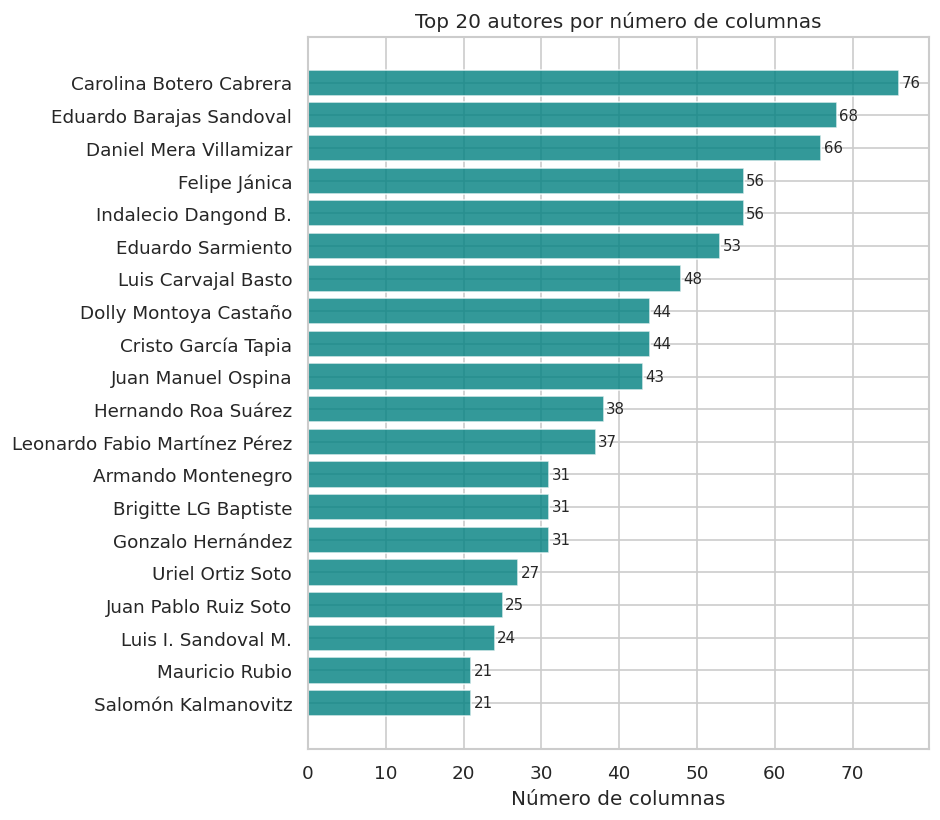

In [11]:
top_autores = por_autor.head(TOP_N)

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top_autores.index[::-1], top_autores['n_columnas'][::-1], color='teal', alpha=0.8)
ax.set_xlabel('Número de columnas')
ax.set_title(f'Top {TOP_N} autores por número de columnas')
for i, v in enumerate(top_autores['n_columnas'][::-1]):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_top_autores.png', bbox_inches='tight')
plt.show()

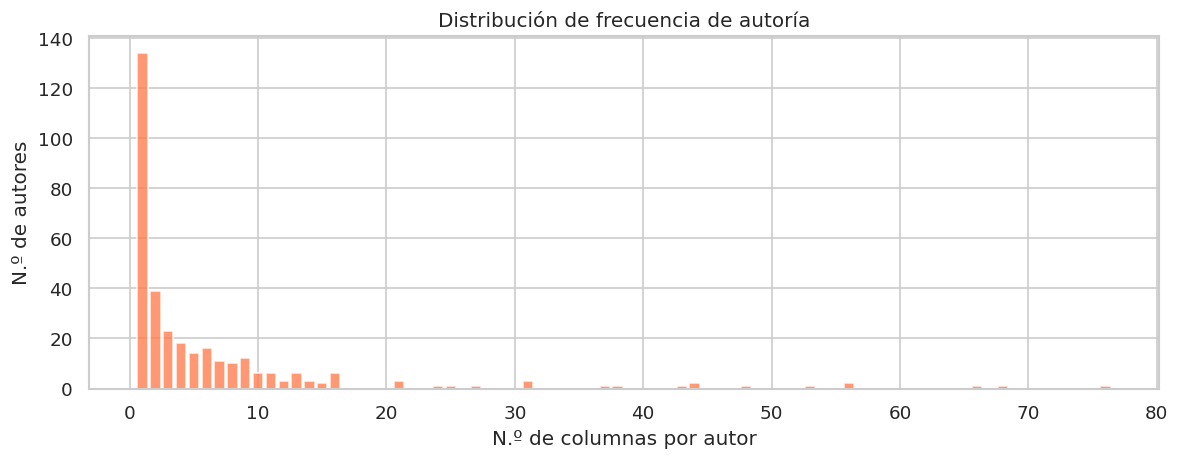

Top 10 autores concentran el 27.0% del corpus


In [12]:
# Distribución de frecuencia de autoría (¿cuántos autores tienen 1, 2, 3… columnas?)
freq_dist = por_autor['n_columnas'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(freq_dist.index, freq_dist.values, color='coral', alpha=0.8)
ax.set_xlabel('N.º de columnas por autor')
ax.set_ylabel('N.º de autores')
ax.set_title('Distribución de frecuencia de autoría')
plt.tight_layout()
plt.savefig('fig_dist_autoria.png', bbox_inches='tight')
plt.show()

# Concentración: % del corpus que producen los top-10 autores
top10_share = por_autor.head(10)['n_columnas'].sum() / len(df) * 100
print(f"Top 10 autores concentran el {top10_share:.1f}% del corpus")

## 6. Cruce: autores por periódico

In [13]:
# Autores exclusivos vs. compartidos entre periódicos
autores_por_diario = df.groupby('Autor')['Diario'].nunique()
print("Autores que publican en un solo periódico:",  (autores_por_diario == 1).sum())
print("Autores que publican en dos periódicos:",     (autores_por_diario == 2).sum())
print("Autores que publican en tres periódicos:",    (autores_por_diario == 3).sum())

Autores que publican en un solo periódico: 324
Autores que publican en dos periódicos: 6
Autores que publican en tres periódicos: 0


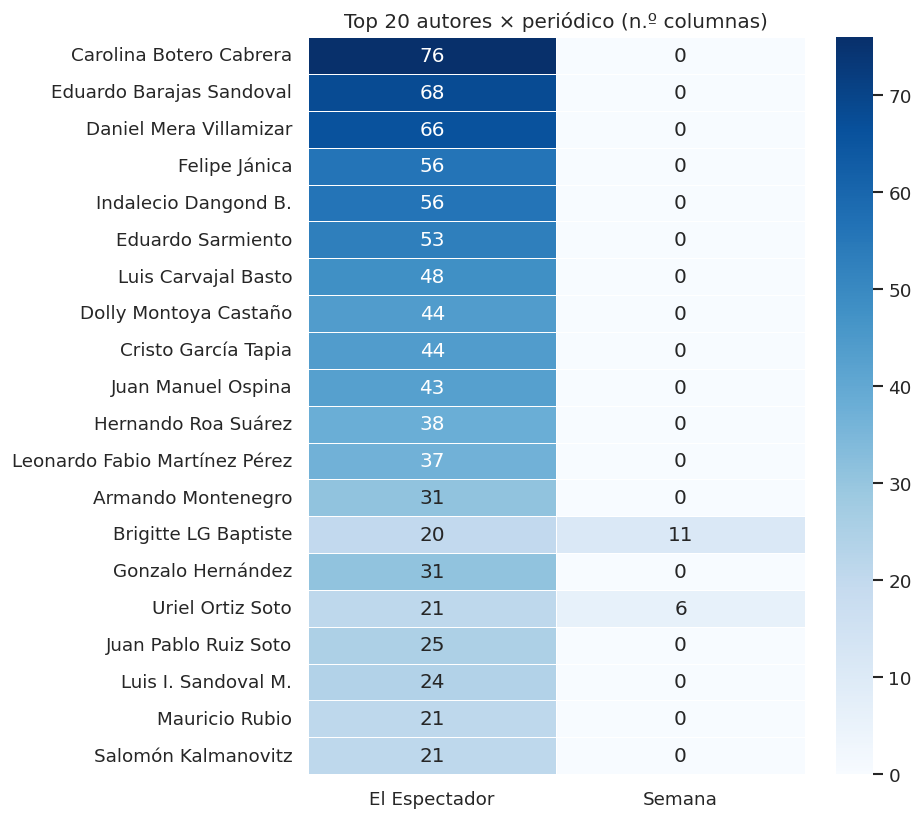

In [14]:
# Heatmap: top autores × periódico
top_autores_idx = por_autor.head(TOP_N).index
pivot = (
    df[df['Autor'].isin(top_autores_idx)]
      .groupby(['Autor', 'Diario'])
      .size()
      .unstack(fill_value=0)
      .loc[top_autores_idx]   # mantiene orden por frecuencia
)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title(f'Top {TOP_N} autores × periódico (n.º columnas)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('fig_heatmap_autor_diario.png', bbox_inches='tight')
plt.show()

## 7. Longitud de las columnas

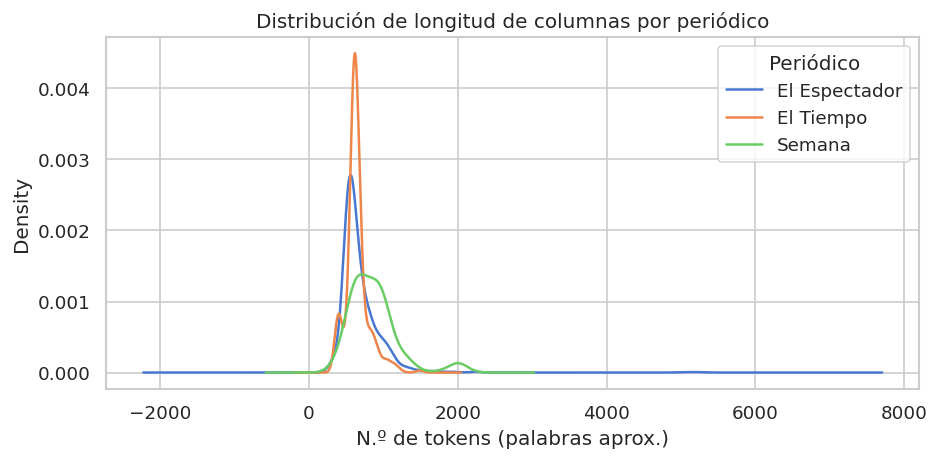

,count,mean,std,min,25%,50%,75%,max
Diario,,,,,,,,
El Espectador,1571.0,687.2,300.6,257.0,531.0,607.0,773.5,5223.0
El Tiempo,288.0,644.3,153.4,366.0,588.0,621.0,676.5,1486.0
Semana,194.0,866.1,332.7,322.0,641.2,820.0,998.0,2124.0


In [15]:
# Distribución de longitud por periódico
fig, ax = plt.subplots(figsize=(8, 4))
for diario, grupo in df.groupby('Diario'):
    grupo['n_tokens'].plot(kind='kde', ax=ax, label=diario)
ax.set_xlabel('N.º de tokens (palabras aprox.)')
ax.set_title('Distribución de longitud de columnas por periódico')
ax.legend(title='Periódico')
plt.tight_layout()
plt.savefig('fig_longitud_tokens.png', bbox_inches='tight')
plt.show()

df.groupby('Diario')['n_tokens'].describe().round(1)

## 8. Nube de palabras

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Stopwords NLTK en español
STOPWORDS_NLTK = set(stopwords.words('spanish'))

STOPWORDS_CUSTOM = {
    # Formas verbales no capturadas por NLTK
    'debe', 'hacer', 'tener', 'decir', 'pueden', 'puede',
    'hace', 'sido', 'deben', 'cada',

    # Adverbios y conectores discursivos
    'además', 'ahora', 'cómo', 'también', 'sino', 'tan',
    'siempre', 'aunque', 'mientras', 'hacia', 'embargo',
    'después', 'según', 'frente', 'pues',

    # Cuantificadores, comparativos y términos genéricos
    'mayor', 'mejor', 'nuevo', 'millones', 'manera', 'forma',
    'ejemplo', 'cuenta', 'parte', 'caso', 'hecho', 'vez',
    'bien', 'menos', 'gran', 'mismo', 'todas', 'grandes',
    'general', 'importante', 'posible', 'cosas', 'muchas',
    'cualquier', 'tres', 'primera', 'solo', 'ello', 'lugar',

    # Términos demasiado generales para el dominio
    'colombia', 'país', 'países', 'año', 'años', 'mundo',
    'tiempo', 'proceso', 'acuerdo', 'sistema', 'personas',
    'vida', 'cambio', 'decir', 'pues',

    # Artefactos de scraping
    'web', 'archive', 'https', 'http', 'www',
}

STOPWORDS = STOPWORDS_NLTK | STOPWORDS_CUSTOM

# Unión de ambos conjuntos
STOPWORDS = STOPWORDS_NLTK | STOPWORDS_CUSTOM


def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'https?://\S+', '', texto)
    texto = re.sub(r'[^a-záéíóúüñ\s]', '', texto)
    tokens = texto.split()
    return [t for t in tokens if t not in STOPWORDS and len(t) > 3]

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\karen\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


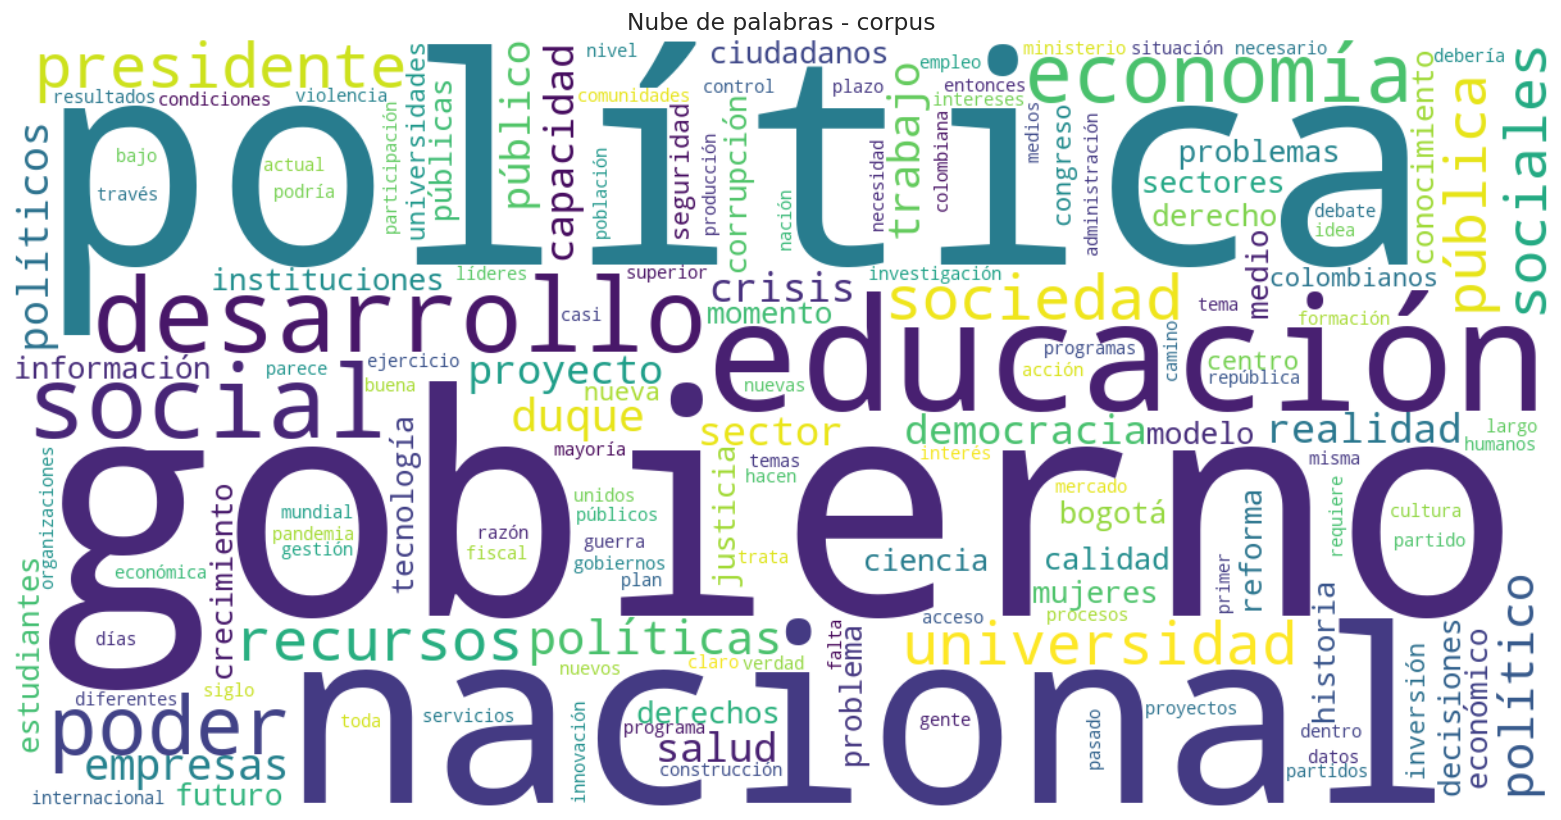

In [22]:
# --- Nube general del corpus ---

# Regenerar frecuencias con stopwords actualizadas
tokens_todos = []
for texto in df['Texto'].dropna():
    tokens_todos.extend(limpiar_texto(texto))

freq = Counter(tokens_todos)

# Nube actualizada
wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='viridis',
    max_words=150,
    collocations=False,
).generate_from_frequencies(freq)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('Nube de palabras - corpus', fontsize=14)
plt.tight_layout()
plt.savefig('wordcloud_general.png', dpi=150, bbox_inches='tight')
plt.show()